In [10]:
#!/usr/bin/env python
import matplotlib.pyplot as plt
import numpy as np
from lmfit.models import LorentzianModel, QuadraticModel, VoigtModel, LinearModel,PseudoVoigtModel,Model
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from pathlib import Path
mpl.rc('text', usetex=False)
def add_peak(prefix, center, amplitude=0.1, sigma=0.05,gamma = 0.05):
    peak = VoigtModel(prefix=prefix)
    pars = peak.make_params()
    pars[prefix + 'center'].set(center,min=2000,max =2200)
    pars[prefix + 'amplitude'].set(amplitude, min = 0.0001,max=500)
    pars[prefix + 'sigma'].set(sigma, min=0.001,max =40, vary = False)
    pars[prefix + 'gamma'].set(gamma, min=0, max=100,vary = True)
    return peak, pars
def add_fancy_peak(prefix, center, amplitude, fwhm, fraction = 0.0):
    peak = PseudoVoigtModel(prefix=prefix)
    pars = peak.make_params()
    if prefix =="lz5_" or prefix =="lz6_"or prefix =="lz7_" :
        pars[prefix + 'center'].set(center,min=center-15,max =center+15,vary=False)
        pars[prefix + 'amplitude'].set(amplitude, min = 0,max=10)
        #pars[prefix + 'fwhm'].set(fwhm,min=fwhm-5,max =fwhm+5,vary=True,expr=None)
        pars[prefix + 'fraction'].set(fraction, vary=False)
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-10,max =fwhm/2+10,vary=False)
    elif prefix =="lz9_" or prefix =="lz9_":
        pars[prefix + 'center'].set(center,min=center-5,max =center+5,vary=True)
        pars[prefix + 'amplitude'].set(amplitude, min = 0,max=10)
        #pars[prefix + 'fwhm'].set(fwhm,min=fwhm-5,max =fwhm+5,vary=True,expr=None)
        pars[prefix + 'fraction'].set(fraction, min = 0 ,max = 1,vary = False)
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-5,max =fwhm/2+5,vary=True)
    else:
        pars[prefix + 'center'].set(center,min=center-5,max =center+5,vary=False)
        pars[prefix + 'amplitude'].set(amplitude, min = 0,max=10)
        #pars[prefix + 'fwhm'].set(fwhm,min=fwhm-5,max =fwhm+5,vary=True,expr=None)
        pars[prefix + 'fraction'].set(fraction, min = 0 ,max = 1,vary = False)
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-5,max =fwhm/2+5,vary=False)
    return peak, pars
def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d
def get_super(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)
def get_sub(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)

In [28]:
#Clears Data
fit_tracker = {}
data_tracker = {}

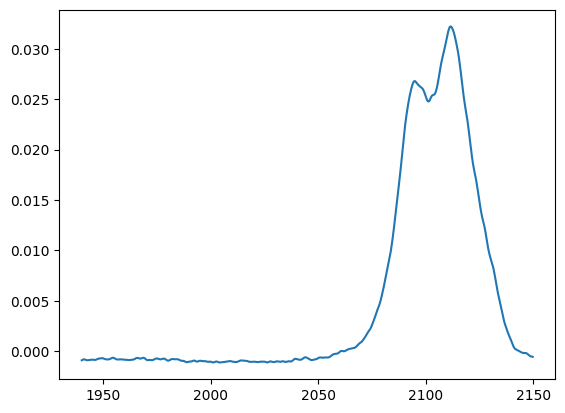

In [8]:

wn1 = 1940 # Start in wn
wn2= 2150 # End in wn
# Choose .csv data file and turn it into dataframe
file_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_60Min.csv'
colnames = ["wavenum" , "val"] #Defines the column tites for a csv without titles
# Edit the CSV Name here for your first file
file = pd.read_csv(file_name, names = colnames) #,header=[0,1]) 
drifts_df = pd.DataFrame(file)
#This works for the CSV that is exported from the OMNIC software, where Wavenumber is the first column and the Units are the second column
#All CSVs imported together must have the same Wavenumber range! (Future code will be able to handle data with different ranges]
wavenum = drifts_df.iloc[:, 0]
in_drifts = drifts_df.set_index("wavenum")
#This step adds all the Data name, the data, and whether you want it to be included in the current plot with a true false statement. 
#This info is added as a list to a large list that compiles all your data
#The data name is used as the legend name for the data
datalist = [["data",in_drifts.copy, True]]
wn1_df = wavenum.iloc[(wavenum-wn1).abs().argsort()[:1]].index[0]
wn2_df = wavenum.iloc[(wavenum-wn2).abs().argsort()[:1]].index[0] 

xdat = wavenum.iloc[wn1_df:wn2_df]
ydat1 = drifts_df.iloc[wn1_df:wn2_df,1]

file = pd.read_csv('FTIR_231101_Al2O310_95KBr_CO_1%_25C.csv', names = colnames) 
#file = pd.read_csv('FTIR_241107_CuAl2O3_Reduce_500ppmCO_15min.csv', names = colnames) 
df = pd.DataFrame(file)
drifts_df = df.iloc[:]
in_drifts = drifts_df.set_index("wavenum")
datalist.append(['CO', in_drifts.copy, True])
wavenum = drifts_df.iloc[:, 0]


#Change true to false for any one you want to exclude from a given plot.
wn1_df = wavenum.iloc[(wavenum-wn1).abs().argsort()[:1]].index[0]
wn2_df = wavenum.iloc[(wavenum-wn2).abs().argsort()[:1]].index[0] 


xdat = wavenum.iloc[wn1_df:wn2_df].to_numpy()
ydat2 = in_drifts.iloc[wn1_df:wn2_df,:]
#ydat2.index=ydat1.index

ydat = ydat1.to_numpy()

plt.plot(xdat, ydat, label='sub')
#plt.plot(xdat, ydat1, label='data')

#plt.gca().invert_xaxis()
#plt.legend()
#file = pd.read_csv('Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_postexp60min.csv', names = colnames) 

#df = pd.DataFrame(file)
#drifts_df = df.iloc[:]
#datalist.append(['Sub500ppm', drifts_df.iloc[:, 1], True])
#wavenum = drifts_df.iloc[:, 0]
#Finds the location of that wavenumber in the index
#wn1_df = wavenum.iloc[(wavenum-wn1).abs().argsort()[:1]].index[0]
#wn2_df = wavenum.iloc[(wavenum-wn2).abs().argsort()[:1]].index[0] 
#xdat = wavenum.iloc[wn1_df:wn2_df]
#ydat = datalist[2][1].iloc[wn1_df:wn2_df]
#ydat1.index = ydat.index



[[Model]]
    ((((Model(parabolic, prefix='bkg_') + Model(pvoigt, prefix='lz1_')) + Model(pvoigt, prefix='lz2_')) + Model(pvoigt, prefix='lz3_')) + Model(pvoigt, prefix='lz4_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 65
    # data points      = 871
    # variables        = 7
    chi-square         = 0.00135501
    reduced chi-square = 1.5683e-06
    Akaike info crit   = -11634.3951
    Bayesian info crit = -11601.0077
    R-squared          = 0.98481493
[[Variables]]
    bkg_a:          6.9158e-08 +/- 1.3762e-08 (19.90%) (init = -5.5513e-07)
    bkg_b:         -2.7365e-04 +/- 5.6195e-05 (20.54%) (init = 0.000108225)
    bkg_c:          0.26975517 +/- 0.05733474 (21.25%) (init = -0.04)
    lz1_amplitude:  0.42155070 +/- 0.00399482 (0.95%) (init = 0)
    lz1_center:     2099.9 (fixed)
    lz1_sigma:      7.55 (fixed)
    lz1_fraction:   0 (fixed)
    lz1_fwhm:       15.1000000 +/- 0.00000000 (0.00%) == '2.0000000*lz1_sigma'
    lz1_height:     0.0262

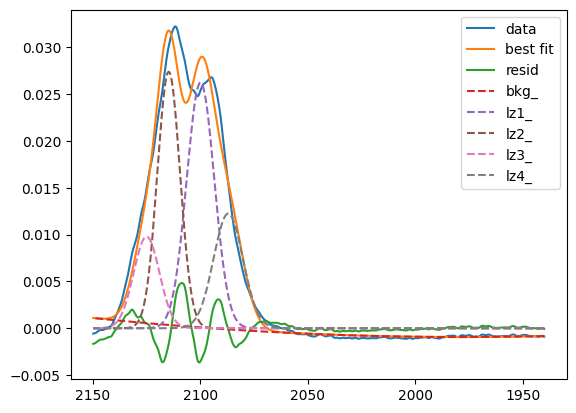

In [11]:
model = QuadraticModel(prefix='bkg_')
#model = Model(cubic,prefix='bkg_')
params = model.make_params(a=-5.5513e-07 , b=0.000108225 , c=-0.04 )

#rough_peak_positions = (2099.9,2114.7,2125.0,2088)

#rough_fwhm = (15.1,12.4,14.1,15.5) 
rough_peak_positions = [2099.9,2114.7,2125,2087]#,2009,1981.1,2034.6,2107.5]

rough_fwhm = [15.1,12.4,14.1,16.1]# ,30.2,29.5,24.7,7.73]
rough_ampl = [-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001] 
for i, cen in enumerate(rough_peak_positions):
    peak, pars = add_fancy_peak('lz%d_' % (i+1), cen, rough_ampl[i],rough_fwhm[i])
    model = model + peak
    params.update(pars)

init = model.eval(params, x=xdat)
result = model.fit(ydat, params, x=xdat)
comps = result.eval_components()
fit_areas = {}
for name, comp in comps.items():
    fit_areas[name] = np.trapz(y = comp, x = xdat) 
print(result.fit_report(min_correl=0.5))
print(fit_areas)
plt.plot(xdat, ydat, label='data')
plt.plot(xdat, result.best_fit, label='best fit')
plt.plot(xdat, ydat-result.best_fit, label='resid')
#plt.axhline(y=0)
for name, comp in comps.items():
    plt.plot(xdat, comp, '--', label=name)
plt.gca().invert_xaxis()
plt.legend(loc='upper right')

plt.show()

In [32]:
slice_time ="500ppmSubCO"
fit_tracker[slice_time] = {}
data_tracker[slice_time] = {}
fit_tracker[slice_time]["result"] = result.fit_report(show_correl = False)
fit_tracker[slice_time]["names"] = []
fit_tracker[slice_time]["locations"] = []
fit_tracker[slice_time]["FWHM"] = []
fit_tracker[slice_time]["areas"] = []
fit_tracker[slice_time]["areas_error"] = []
data_tracker[slice_time]["xdat"] = xdat.to_numpy() 
data_tracker[slice_time]["ydat"] = ydat
data_tracker[slice_time]["best fit"] = result.best_fit
for name, comp in comps.items():
    data_tracker[slice_time][name] = comp
    if name != "bkg_":
        #if name == 
        fit_tracker[slice_time]["names"].append(name)
        fit_tracker[slice_time]["locations"].append(result.best_values[name+"center"])
        fit_tracker[slice_time]["FWHM"].append(result.params[name+"fwhm"].value)
        fit_tracker[slice_time]["areas"].append(np.trapz(y = comp, x = xdat))
        fit_tracker[slice_time]["areas_error"].append(result.params[name+"amplitude"].stderr)
        

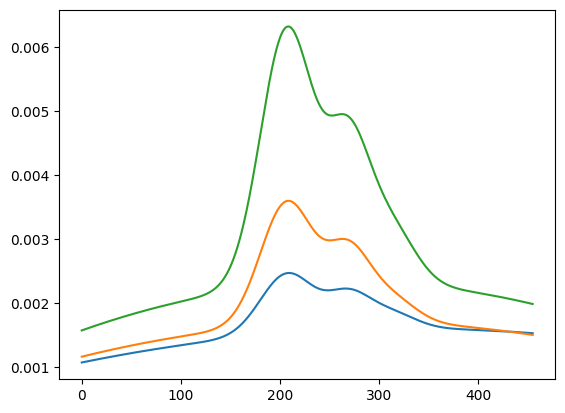

In [15]:
plt.plot(data_tracker["100ppm"]["best fit"])
plt.plot(data_tracker["200ppm"]["best fit"])
plt.plot(data_tracker["500ppm"]["best fit"])

In [36]:
print(fit_tracker["0.0 pct"]["locations"])
print(fit_tracker["0.1 pct"]["locations"])
print(fit_tracker["0.5 pct"]["locations"])
print(fit_tracker["1.0 pct"]["locations"])
print(fit_tracker["2.0 pct"]["locations"])
print(fit_tracker["4.0 pct"]["locations"])
print(data_tracker["2.0 pct"]["lz5_"])

[837.9642431126348, 858.4412249304663, 887.3653813237864, 923.4783471996037, 943.3157053634375, 955.2549376456207, 966.8201380682939]
[837.9690725929692, 858.4674005968789, 887.3732295029209, 923.496184077331, 943.311339336802, 955.2359943946358, 966.8116993081495]
[837.9753091152832, 858.4580537717086, 887.3161296004506, 923.4747250478183, 943.3181100320082, 955.247039064662, 966.7975754775321]
[837.9742542716489, 858.440301019641, 887.5039379712441, 923.3763099226541, 943.2361132804238, 955.211306505506, 966.8242729300189]
[837.9874289558975, 858.5262493283032, 887.2518959017226, 922.9308241020915, 943.1357248720724, 954.9429727475266, 966.785754819217]
[838.0125000481119, 858.5856305280452, 887.2534841175759, 923.0804540111217, 942.9707781967772, 954.7088019297179, 966.795759873755]
[-9.38125043e-05 -9.77028940e-05 -1.01838772e-04 -1.06241042e-04
 -1.10933009e-04 -1.15940410e-04 -1.21291876e-04 -1.27019516e-04
 -1.33159046e-04 -1.39750550e-04 -1.46838983e-04 -1.54475216e-04
 -1.6271

In [9]:
fit_dict = {"data":ydat.values, "best fit":result.best_fit}
for name, comp in comps.items():
    fit_dict[name] = comp
df_fit =pd.DataFrame(fit_dict,index=xdat)
df_fit.to_csv("240703_CuRh0.04_RT post CO 30 min_30 C backrgound 21" + "Best_Fit2000_2200.csv",',')
f = open("240703_CuRh0.04_RT post CO 30 min_30 C backrgound 21" + "Best_Fit2000_2200.txt", "w")
f.write(result.fit_report(min_correl=0.5))
f.close()

In [33]:
#Saving the fits
data_fit_tracker = fit_tracker
data_data_tracker = data_tracker
file_name = 'Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_postexp60min_V2w107'
times = []
frames = []
reports = ''
datas = []
for time, d in enumerate(data_fit_tracker):
    times.append(d)
    if "result" in data_fit_tracker[d]:
        reports=(reports+str(d) +"\n"+ data_fit_tracker[d]["result"]+"\n\n")
    #del data_fit_tracker[d]["result"]
    data_fit_tracker[d].pop("result", None)
    frames.append(pd.DataFrame.from_dict(data_fit_tracker[d], orient='index'))
for time, d in enumerate(data_data_tracker):
    datas.append(pd.DataFrame.from_dict(data_data_tracker[d], orient='index'))
df_fit=pd.concat(frames, keys=times)
df_datum=pd.concat(datas, keys=times)
df_fit.to_csv(file_name + "Best_Fitpeak.csv",',')
df_datum.to_csv(file_name + "Best_Fit_Valuespeak.csv",',')
f = open(file_name + "Best_Fitpeak.txt", "w")
f.write(reports)
f.close()

C:\Users\jdnor\AppData\Local\Temp\ipykernel_3524\3849543773.py:20: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_fit.to_csv(file_name + "Best_Fitpeak.csv",',')
C:\Users\jdnor\AppData\Local\Temp\ipykernel_3524\3849543773.py:21: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_datum.to_csv(file_name + "Best_Fit_Valuespeak.csv",',')


[0.001, 0.0068, 0.0126, 0.0184, 0.0242, 0.03]


C:\Users\jdnor\AppData\Local\Temp\ipykernel_3524\3910098148.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize = 3*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))


<Figure size 640x480 with 0 Axes>

<Figure size 800x600 with 0 Axes>

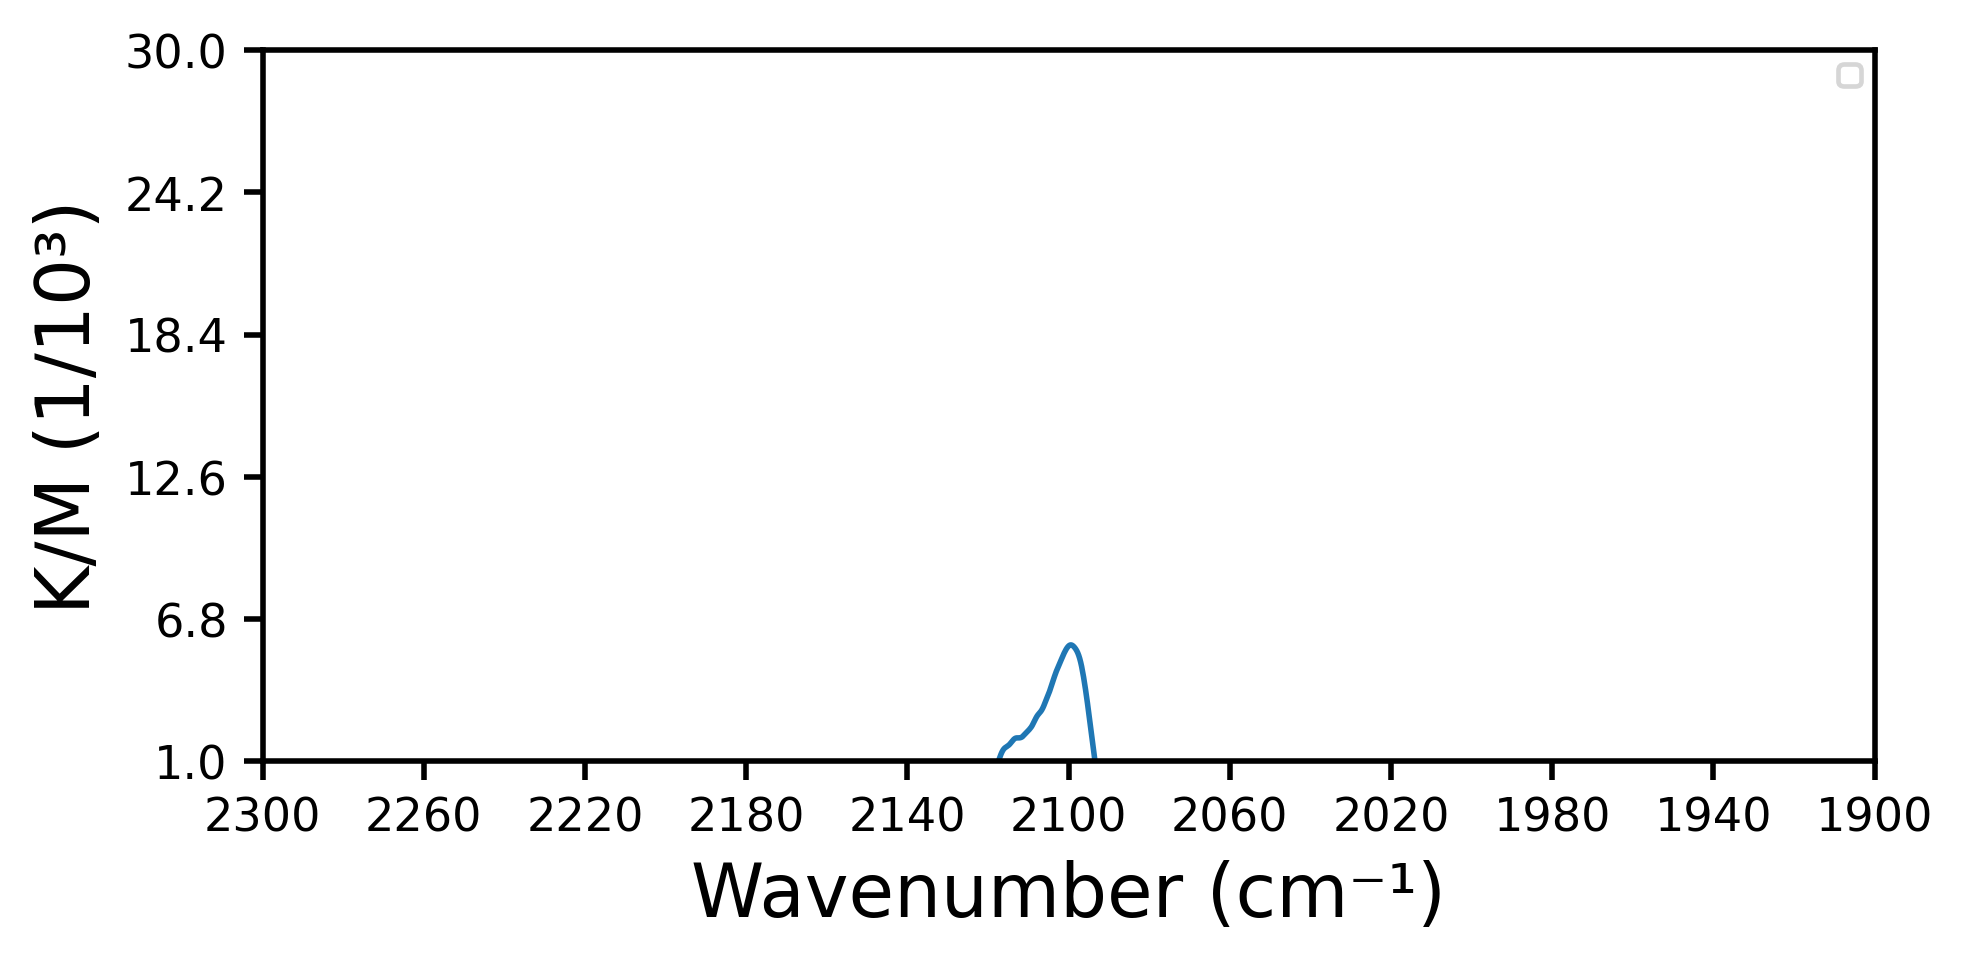

In [6]:
#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 2

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
colors=["crimson","chocolate","slateblue","firebrick","black","slategray","magenta","darkturquoise"]#
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = 'FTIR_241107_CuAl2O3_Reduce_500ppmCO_postexp60min'

plt.figure(linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(6, 3),linewidth = 0.6*font_size)
#Plotting Fitted Data
#ax.plot(xdat, ydat-comps["bkg_"], label='data',linewidth = 0.6*font_size)
#ax.plot(xdat, result.best_fit-comps["bkg_"], label='best fit',linewidth = 0.6*font_size)
#ax.plot(xdat, ydat-result.best_fit, label='resid',linewidth = 0.6*font_size)
#Plotting a single spectrum
ax.plot(wavenum, datalist[2][1],linewidth = 0.6*font_size)
i = 0
#for name, comp in comps.items():
 #   print(name)
  #  if name != "bkg_":
   #     ax.plot(xdat, comp, '--', label=name,linewidth = 0.6*font_size,color = colors[i])
    #i+=1

#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
ax.set_ylabel("K/M (1/10"+ get_super("3")+")", fontsize = 8*font_size)#,labelpad=5)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2300 #High Range
xlow = 1900 #Low Range
xpoints = 11 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.03 #High Range
ylow = 0.001 #Low Range
ypoints = 6 #How many points you want on your axis
ydigits = 4 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)
ax.set_yticks(ylabels)
ydistort = []
for i,y in enumerate(ylabels):
    ydistort.append(round(y*1000,1))
ax.set_yticklabels(ydistort)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

bkg_
lz1_
lz2_
lz3_
lz4_
lz5_
lz6_
lz7_
lz8_
[-0.001, 0.0004, 0.0018, 0.0032, 0.0046, 0.006]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

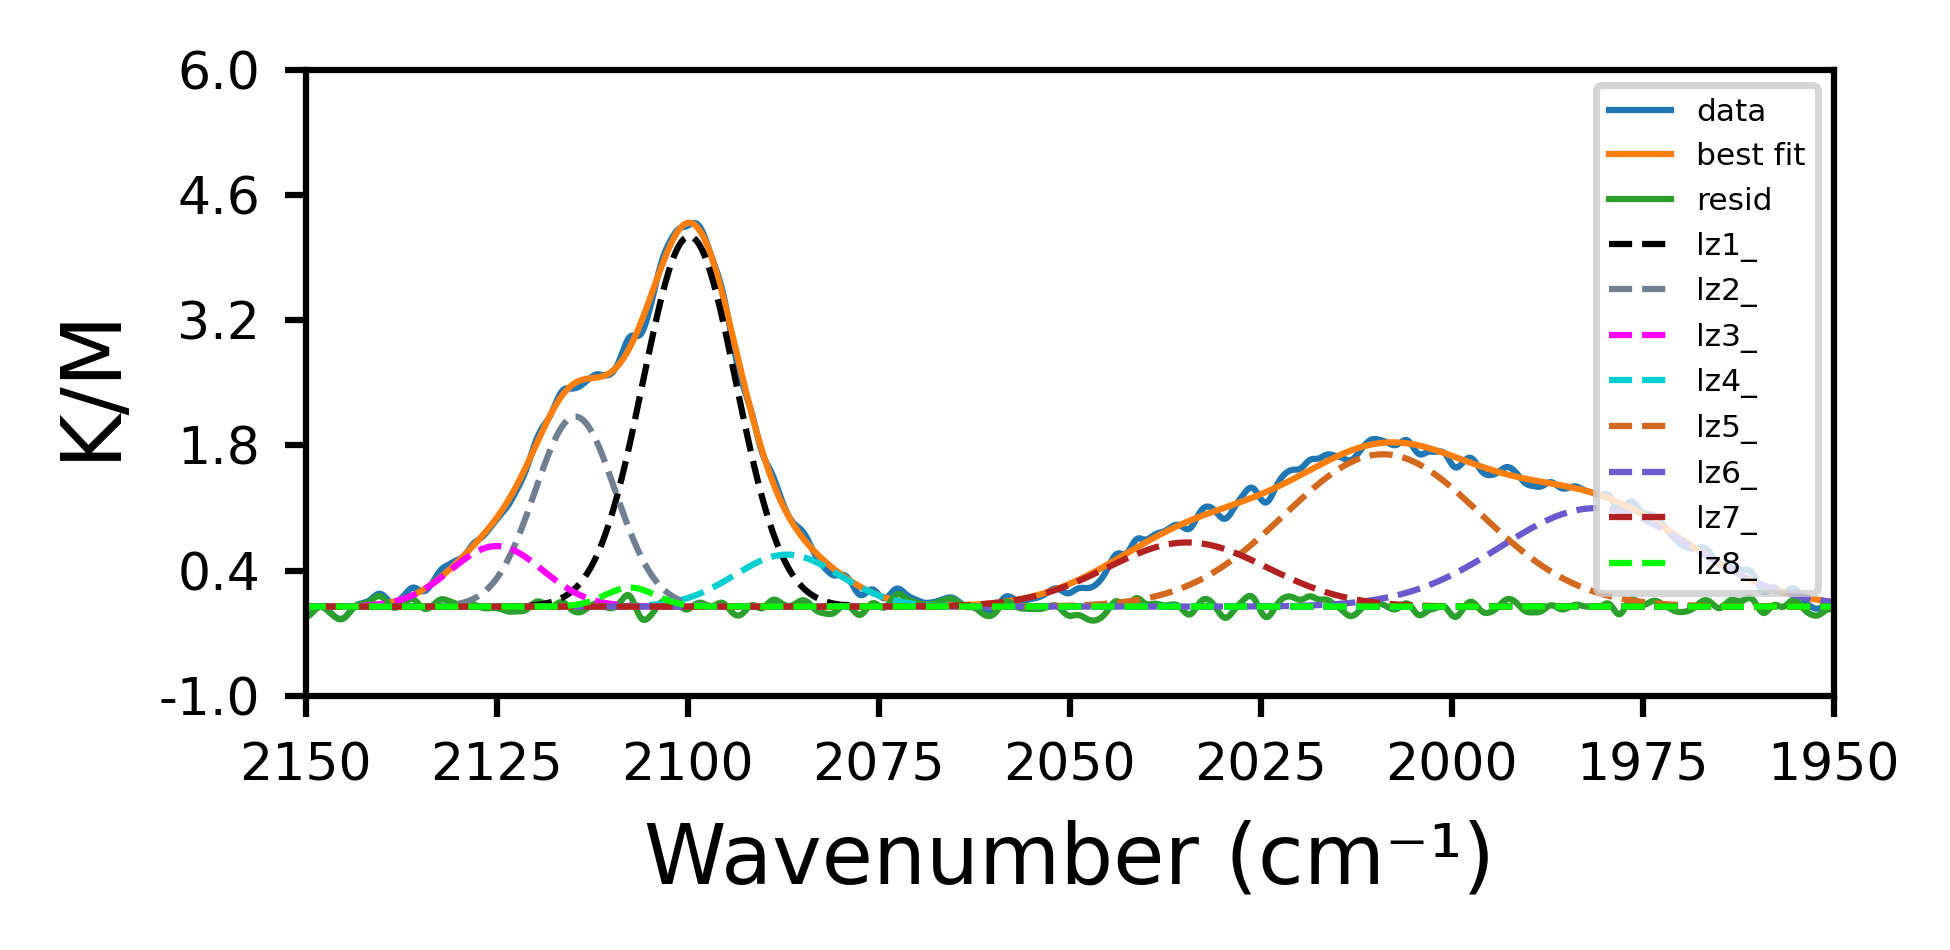

In [29]:
#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
colors=["black","slategray","magenta","darkturquoise","chocolate","slateblue","firebrick","lime"]#
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = 'Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_60min_V2w107'

plt.figure(linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(4, 2),linewidth = 0.6*font_size)
#Plotting Fitted Data
ax.plot(xdat, ydat-comps["bkg_"], label='data',linewidth = 0.6*font_size)
ax.plot(xdat, result.best_fit-comps["bkg_"], label='best fit',linewidth = 0.6*font_size)
ax.plot(xdat, ydat-result.best_fit, label='resid',linewidth = 0.6*font_size)
#Plotting a single spectrum
#ax.plot(wavenum, datalist[1][1],linewidth = 0.6*font_size)
i = 0
for name, comp in comps.items():
    print(name)
    if name != "bkg_":
        ax.plot(xdat, comp, '--', label=name,linewidth = 0.6*font_size,color = colors[i])
        i+=1

#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
ax.set_ylabel("K/M", fontsize = 8*font_size)#,labelpad=5)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2150 #High Range
xlow = 1950 #Low Range
xpoints = 9 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.006 #High Range
ylow = -0.001 #Low Range
ypoints = 6 #How many points you want on your axis
ydigits = 4 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)
ax.set_yticks(ylabels)
ydistort = []
for i,y in enumerate(ylabels):
    ydistort.append(round(y*1000,1))
ax.set_yticklabels(ydistort)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()